In [1]:
import numpy as np
from matplotlib import pyplot as plt, cm
from mpl_toolkits.mplot3d import Axes3D

domain = 1
nx = 257
ny = 257
dx = domain / (nx - 1)
dy = domain / (ny - 1)

x = np.linspace(0, domain, nx)
y = np.linspace(0, domain, ny)

c = 1
rho = 1
nu = 0.01 # kinematic viscosity (m2/s)
mu = nu * rho

dt = 0.001

# initial conditions
u = np.zeros((nx, ny))
v = np.zeros((nx, ny))
p = np.zeros((nx, ny))

# boundary conditions
# 1- u = 1 at y = 1 (lid)
u[:, -1] = c

# 2- u, v = 0 on the other boundaries
u[0, :] = v[0, :] = 0 # at x = 0
u[:, 0] = v[:, 0] = 0 # at y = 0
u[-1, :] = v[-1, :] = 0 # at x = 1

# 3- dp/dy = 0 at y = 0
p[:, 0] = p[:, 1]

# 4- p = 0 at y = 1
p[:, -1] = 0

# 5- dp/dx = 0 at x = 0, 2
p[0, :] = p[1, :]   # at x=0
p[-1, :] = p[-2, :] # at x=1


# reynold's number
def Re(c, domain, nu):
    print("Reynold's number =", c*domain/nu)

Re(c, domain, nu)

Reynold's number = 100.0


In [2]:
# NS equations

def ns_eqs_single_step(p, u, v):
    un = u.copy()
    vn = v.copy()

    # x-direction
    u[1:-1, 1:-1] = (un[1:-1, 1:-1]-
                    un[1:-1, 1:-1]*(dt/dx)*(un[1:-1, 1:-1] - un[:-2, 1:-1])-
                    vn[1:-1, 1:-1]*(dt/dy)*(un[1:-1, 1:-1] - un[1:-1, :-2])-
                    (dt/(2*rho*dx))*(p[2:, 1:-1] - p[:-2, 1:-1])+
                    (nu)*((dt/(dx**2))*(un[2:, 1:-1] - 2*un[1:-1, 1:-1] + un[:-2, 1:-1])+
                    (dt/(dy**2))*(un[1:-1, 2:] - 2*un[1:-1, 1:-1] + un[1:-1, :-2])))
    
    # y-direction
    v[1:-1, 1:-1] = (vn[1:-1, 1:-1]-
                    un[1:-1, 1:-1]*(dt/dx)*(vn[1:-1, 1:-1] - vn[:-2, 1:-1])-
                    vn[1:-1, 1:-1]*(dt/dy)*(vn[1:-1, 1:-1] - vn[1:-1, :-2])-
                    (dt/(2*rho*dy))*(p[1:-1, 2:] - p[1:-1, :-2])+
                    (nu)*((dt/(dx**2))*(vn[2:, 1:-1] - 2*vn[1:-1, 1:-1] + vn[:-2, 1:-1])+
                    (dt/(dy**2))*(vn[1:-1, 2:] - 2*vn[1:-1, 1:-1] + vn[1:-1, :-2])))
    
    # boundary conditions
    u[0, :] = 0; v[0, :] = 0    # at x = 0
    u[-1, :] = 0; v[-1, :] = 0  # at x = 1
    u[:, -1] = c; v[:, -1] = 0  # at y = 1
    u[:, 0] = 0                 # at y = 0
    v[:, 0] = 0                 # at y = 0
    
    return u, v

In [3]:
# PPE

def ppe(p, u, v, max_iterations=2000, tolerance=1e-4):
    
    du_dx = (u[2:, 1:-1] - u[0:-2, 1:-1])/(2*dx)
    dv_dy = (v[1:-1, 2:] - v[1:-1, 0:-2])/(2*dy)
    du_dy = (u[1:-1, 2:] - u[1:-1, 0:-2])/(2*dy)
    dv_dx = (v[2:, 1:-1] - v[0:-2, 1:-1])/(2*dx)
    
    rhs = np.zeros_like(p)
    rhs[1:-1, 1:-1] = ((dx**2)*(dy**2))/(2*((dx**2)+(dy**2)))*rho*((1/dt)*(du_dx + dv_dy)-
                      (du_dx**2) - (2*du_dy*dv_dx) - (dv_dy**2))
    
    for it in range(max_iterations):
        pn = p.copy()
        p[1:-1, 1:-1] = (((pn[2:, 1:-1] + pn[0:-2, 1:-1])*(dy**2)+
                        (pn[1:-1, 2:] + pn[1:-1, 0:-2])*(dx**2))/(2*((dx**2) + (dy**2)))- 
                        rhs[1:-1, 1:-1])
        
        # boundary conditions
        p[:, 0] = p[:, 1]   # dp/dy = 0 at y = 0
        p[:, -1] = 0        # p = 0 at y = 1
        p[0, :] = p[1, :]   # dp/dx = 0 at x = 0
        p[-1, :] = p[-2, :] # dp/dx = 0 at x = 1

        # calculate L2 norm of the change
        residual = np.sqrt(np.sum((p - pn) ** 2)) / (nx * ny)
        
        if residual < tolerance:
            # then system has converged successfully
            break
    return p

In [4]:
# forward-time backward-space scheme implementation
# update pressure field first using PPE to ensure divergence-free evolution of u and v

def cavity_flow(p, u, v, nt):
    for n in range(nt):
        ppe(p, u, v, max_iterations=2000, tolerance=1e-4)
        ns_eqs_single_step(p, u, v)
    return p, u, v

In [5]:
nt = 100
print('time = ', nt*dt)

time =  0.1


In [6]:
# cavity_flow(p, u, v, nt)

In [7]:
# # Create figure and set dpi and figure size
# fig = plt.figure(figsize=(11,7), dpi=100)
# X, Y = np.meshgrid(x, y)

# # Contourf plot for pressure field with colorbar
# cf = plt.contourf(X, Y, p.T, alpha=0.5, cmap='turbo', levels=20)
# plt.colorbar(cf, label='Pressure')

# # Contour plot for pressure field outlines
# contour = plt.contour(X, Y, p.T, cmap='turbo', levels=10)
# plt.clabel(contour, inline=False, fontsize=12, colors = 'black')

# # Quiver plot for velocity field
# quiv = plt.quiver(X[::2, ::2], Y[::2, ::2], u.T[::2, ::2], v.T[::2, ::2]) 

# # Setting labels for the x and y axes
# plt.xlabel('X', fontsize=12)
# plt.ylabel('Y', fontsize=12)

# # Setting the title for the plot
# plt.title('Pressure and Velocity fields', fontsize=14)

# # Display the plot
# plt.show()

In [8]:
u = np.zeros((nx, ny))
v = np.zeros((nx, ny))
p = np.zeros((nx, ny))

nt = 10000
print('time = ', nt*dt)

time =  10.0


In [9]:
# cavity_flow(p, u, v, nt)

In [10]:
# # Create figure and set dpi and figure size
# fig = plt.figure(figsize=(11,7), dpi=100)

# # Contourf plot for pressure field with colorbar
# cf = plt.contourf(X, Y, p.T, alpha=0.5, cmap='turbo', levels=20)
# plt.colorbar(cf, label='Pressure')

# # Contour plot for pressure field outlines
# contour = plt.contour(X, Y, p.T, cmap='turbo', levels=10)
# plt.clabel(contour, inline=False, fontsize=12, colors = 'black')

# # Quiver plot for velocity field
# quiv = plt.quiver(X[::2, ::2], Y[::2, ::2], u.T[::2, ::2], v.T[::2, ::2]) 

# # Setting labels for the x and y axes
# plt.xlabel('X', fontsize=12)
# plt.ylabel('Y', fontsize=12)

# # Setting the title for the plot
# plt.title('Pressure and Velocity fields', fontsize=14)

# # Display the plot
# plt.show()

In [11]:
# #streamlines plot

# fig = plt.figure(figsize=(11, 7), dpi=100)
# plt.contourf(X, Y, p.T, alpha=0.5, cmap=cm.coolwarm)
# plt.colorbar()
# plt.streamplot(X, Y, u.T, v.T)
# plt.xlabel('X')
# plt.ylabel('Y');

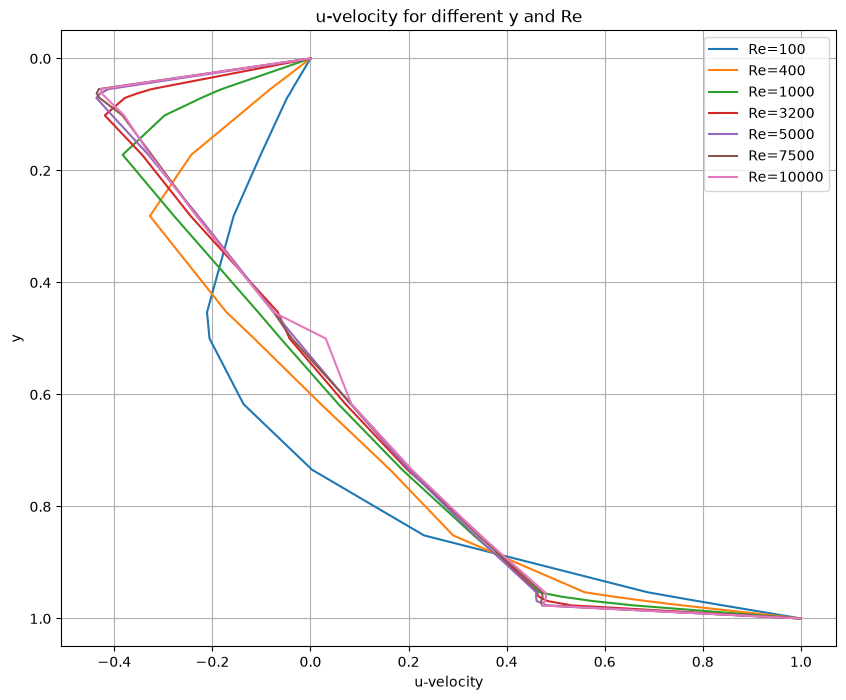

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# reading the txt file
with open('Ghia-1982.txt', 'r') as file:
    lines = file.readlines()

# adjusting the lines range to match your data
lines = lines[1:]  # Adjust these numbers

# processing lines to obtain data
data = [list(map(float, line.split())) for line in lines]

# creating DataFrame from data
df = pd.DataFrame(data, columns=['y', 'Re=100', 'Re=400', 'Re=1000', 'Re=3200', 'Re=5000', 'Re=7500', 'Re=10000'])

# setting y as index
df.set_index('y', inplace=True)

# plotting
plt.figure(figsize=(10,8))
for column in df.columns:
    plt.plot(df[column].values, df.index.values, label=column) # use .values to get numpy arrays

plt.xlabel('u-velocity')
plt.ylabel('y')
plt.title('u-velocity for different y and Re')
plt.legend()
plt.gca().invert_yaxis()  # To invert y-axis
plt.grid(True)
plt.show()

In [13]:
# # validation plot for u variation in y at x = 0.5 against Ghia's data for Re=100

# plt.figure(figsize=(10, 8))

# # plotting the Ghia's comparison dots for Re=100
# plt.plot(df['Re=100'].values, df.index.values, 'o', label='Re=100-Ghia-1982')

# # extracting vertical centerline slice
# u_centerline = u[int(nx / 2), :]

# # plotting the code results as a continuous comparison line
# plt.plot(u_centerline, y, '-', label='Re=100-CFD', linewidth=2.5) 

# plt.xlabel('u-velocity')
# plt.ylabel('y')
# plt.title('u-velocity Profile Validation at Centerline (x = 0.5)')
# plt.legend()
# plt.gca().invert_yaxis()  # inverting y-axis to match lesson coordinate mapping (0 at top)
# plt.grid(True)
# plt.show()

In [14]:
# how is a backward-only scheme in space (x, y) able to survive negative values of u and v 
# without solver overflowing?

# reason: this 2D NS code survives because it includes real, phyiscal viscosity that fights back against
# artifical, numerical viscosity.

# because code is using full explicit time-marching scheme for NS eqns, our time step (dt) is bound by
# 2 distinct physical parameters which are viscous diffusion and advection (convection)

# 1- Viscous CFL condition
# if dt is too large, math overshoots
# dt <= 1 / 2*nu*(1/dx**2 + 1/dy**2)

# 2- Convective CFL condition:
# this condition ensures that fluid particle doesn't travel further than
# 1 grid cell (dx) within a single time step (dt)

# CFL = (|u|*dt/dx) + (|v|*dt/dy) <= 1

# to find our model's stability limit before running
# calculate both and pick the smaller (strictest) value

In [15]:
def timefunc():
    
    # 1- Viscous CFL condition
    dt_visc = 1 / (2*nu*(1/(dx**2) + 1/(dy**2)))

    # 2- Convective CFL condition:
    dt_conv = 1 / ((c/dx) + (c/dy))

    dt_critical = min(dt_visc, dt_conv)

    # as long as our dt < dt_critical, our backward scheme is safe
    # otherwise, we'll have to use true upwind scheme
    print("nt =", nt)
    print("dt =", dt)
    print("Critical time step for stability =", dt_critical)

timefunc()

nt = 10000
dt = 0.001
Critical time step for stability = 0.0003814697265625


In [16]:
# implementing upwind scheme

def ns_eqs_upwind(p, u, v):
    un = u.copy()
    vn = v.copy()
    
    u_positive = un > 0
    v_positive = vn > 0

    # u advection terms
    u_advection_x = np.where(                   # u*du/dx
        u_positive[1:-1, 1:-1],
        un[1:-1, 1:-1]*(un[1:-1, 1:-1] - un[0:-2, 1:-1])/dx,
        un[1:-1, 1:-1]*(un[2:, 1:-1] - un[1:-1, 1:-1])/dx
    )

    u_advection_y = np.where(                   # v*du/dy
        v_positive[1:-1, 1:-1],
        vn[1:-1, 1:-1]*(un[1:-1, 1:-1] - un[1:-1, 0:-2])/dy,
        vn[1:-1, 1:-1]*(un[1:-1, 2:] - un[1:-1, 1:-1])/dy
    )

    u[1:-1, 1:-1] = (un[1:-1, 1:-1] - (dt*u_advection_x) - (dt*u_advection_y)-
                    (dt/(2*rho*dx))*(p[2:, 1:-1] - p[0:-2, 1:-1])+
                    (nu)*((dt/(dx**2))*(un[2:, 1:-1] - 2*un[1:-1, 1:-1] + un[0:-2, 1:-1])+
                    (dt/(dy**2))*(un[1:-1, 2:] - 2*un[1:-1, 1:-1] + un[1:-1, 0:-2])))

    # v advection terms
    v_advection_x = np.where(                   # u*dv/dx
        u_positive[1:-1, 1:-1],
        un[1:-1, 1:-1]*(vn[1:-1, 1:-1] - vn[0:-2, 1:-1])/dx,
        un[1:-1, 1:-1]*(vn[2:, 1:-1] - vn[1:-1, 1:-1])/dx
    )

    v_advection_y = np.where(                   # v*dv/dy
        v_positive[1:-1, 1:-1],
        vn[1:-1, 1:-1]*(vn[1:-1, 1:-1] - vn[1:-1, 0:-2])/dy,
        vn[1:-1, 1:-1]*(vn[1:-1, 2:] - vn[1:-1, 1:-1])/dy
    )

    v[1:-1, 1:-1] = (vn[1:-1, 1:-1] - (dt*v_advection_x) - (dt*v_advection_y) -
                    (dt/(2*rho*dy))*(p[1:-1, 2:] - p[1:-1, 0:-2]) +
                    (nu)*((dt/(dx**2))*(vn[2:, 1:-1] - 2*vn[1:-1, 1:-1] + vn[0:-2, 1:-1]) +
                    (dt/(dy**2))*(vn[1:-1, 2:] - 2*vn[1:-1, 1:-1] + vn[1:-1, 0:-2])))
    
    # boundary conditions
    u[0, :] = 0; v[0, :] = 0   # at x = 0
    u[-1, :] = 0; v[-1, :] = 0 # at x = 1
    u[:, 0] = 0; v[:, 0] = 0   # at y = 0   added missing bottom wall BC
    u[:, -1] = c; v[:, -1] = 0 # at y = 1   enforced last
    
    return u, v

In [ ]:
# to compare against Ghia et al. 1982, solver must evolve to steady-state
# so i'll implement a time-marching solver that automatically stops when the flow reaches steady state

# max_nt: the absolute maximum number of iterations (safety net)
# conv_tol: the convergence tolerance for the velocity residuals

# cavity flow with upwind scheme

def upwind_cavity_flow(p, u, v, max_nt, conv_tol=1e-6):
    
    for n in range(max_nt):

        # saving the previous state before updating
        u_old = u.copy()
        v_old = v.copy()
        
        ppe(p, u, v, max_iterations=2000, tolerance=1e-4)
        ns_eqs_upwind(p, u, v)
        
        # calculating the maximum absolute difference
        u_diff = np.max(np.abs(u - u_old))
        v_diff = np.max(np.abs(v - v_old))
        
        # checking for steady state convergence
        if u_diff < conv_tol and v_diff < conv_tol:
            print(f"steady state reached at iteration {n}")
            print(f"Physical Time Simulated = {n * dt:.4f} seconds")
            print(f"Final Residuals: u_diff = {u_diff:.2e}, v_diff = {v_diff:.2e}")
            break
    else:
        # This triggers only if the loop finishes max_nt without breaking
        print(f"Warning: Reached max iterations ({max_nt}) without hitting tolerance {conv_tol}.")
        print(f"Current Residuals: u_diff = {u_diff:.2e}, v_diff = {v_diff:.2e}")
        print("You may need to increase max_nt or check for numerical instability.")

    return p, u, v

In [18]:
# new setup for Re = 1000

nu = 0.001
mu = nu * rho # updating mu

nt = 50000
max_nt = nt

# initial conditions
u = np.zeros((nx, ny))
v = np.zeros((nx, ny))
p = np.zeros((nx, ny))
u[:, -1] = c

timefunc()
Re(c, domain, nu)

nt = 50000
dt = 0.001
Critical time step for stability = 0.001953125
Reynold's number = 1000.0


In [19]:
dt = 0.001
upwind_cavity_flow(p, u, v, max_nt, conv_tol=1e-6)

steady state reached at iteration 33332
Physical Time Simulated = 33.3320 seconds
Final Residuals: u_diff = 1.00e-06, v_diff = 9.83e-07


(array([[-0.00153328, -0.00153328, -0.00153642, ..., -0.12155143,
         -0.24774213,  0.        ],
        [-0.00153328, -0.00153328, -0.00153642, ..., -0.12155143,
         -0.24774213,  0.        ],
        [-0.00153013, -0.00153013, -0.00153327, ..., -0.08088392,
         -0.1441444 ,  0.        ],
        ...,
        [-0.00477795, -0.00477795, -0.0047735 , ...,  0.3566783 ,
          0.4508785 ,  0.        ],
        [-0.00477347, -0.00477347, -0.00476901, ...,  0.41497326,
          0.54819227,  0.        ],
        [-0.00477347, -0.00477347, -0.00476901, ...,  0.41497326,
          0.54819227,  0.        ]], shape=(257, 257)),
 array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  1.00000000e+00],
        [ 0.00000000e+00,  3.16214967e-07,  4.04005263e-06, ...,
          6.41550281e-02,  2.61569389e-01,  1.00000000e+00],
        [ 0.00000000e+00,  3.38048027e-06,  1.34950569e-05, ...,
          1.10093792e-01,  3.63225292e

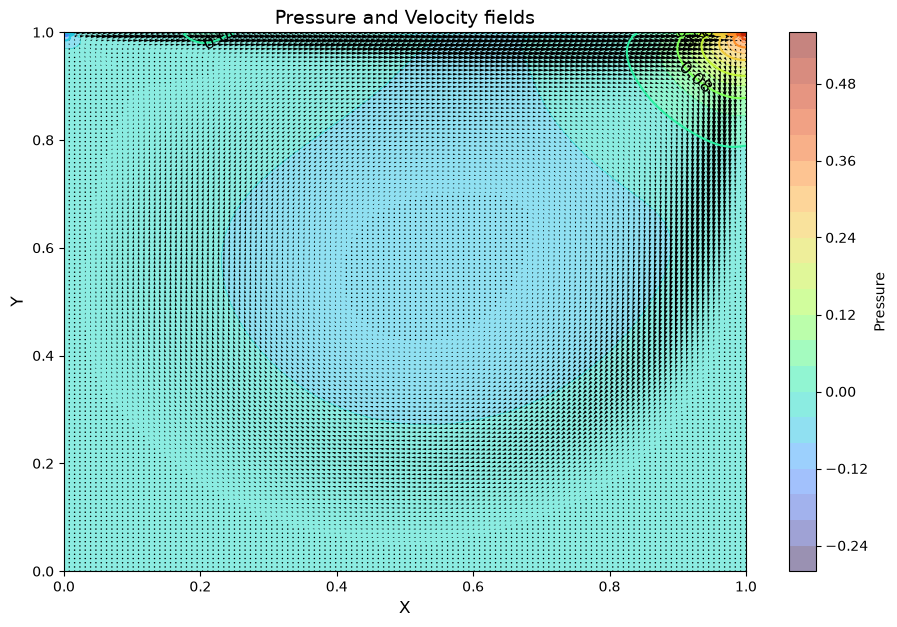

In [ ]:
X, Y = np.meshgrid(x, y)
# Create figure and set dpi and figure size
fig = plt.figure(figsize=(11,7), dpi=100)

# Contourf plot for pressure field with colorbar
cf = plt.contourf(X, Y, p.T, alpha=0.5, cmap='turbo', levels=20)
plt.colorbar(cf, label='Pressure')

# Contour plot for pressure field outlines
contour = plt.contour(X, Y, p.T, cmap='turbo', levels=10)
plt.clabel(contour, inline=False, fontsize=12, colors = 'black')

# Quiver plot for velocity field
quiv = plt.quiver(X[::2, ::2], Y[::2, ::2], u.T[::2, ::2], v.T[::2, ::2]) 

# Setting labels for the x and y axes
plt.xlabel('X', fontsize=12)
plt.ylabel('Y', fontsize=12)

# Setting the title for the plot
plt.title('Pressure and Velocity fields', fontsize=14)

# Display the plot
plt.show()

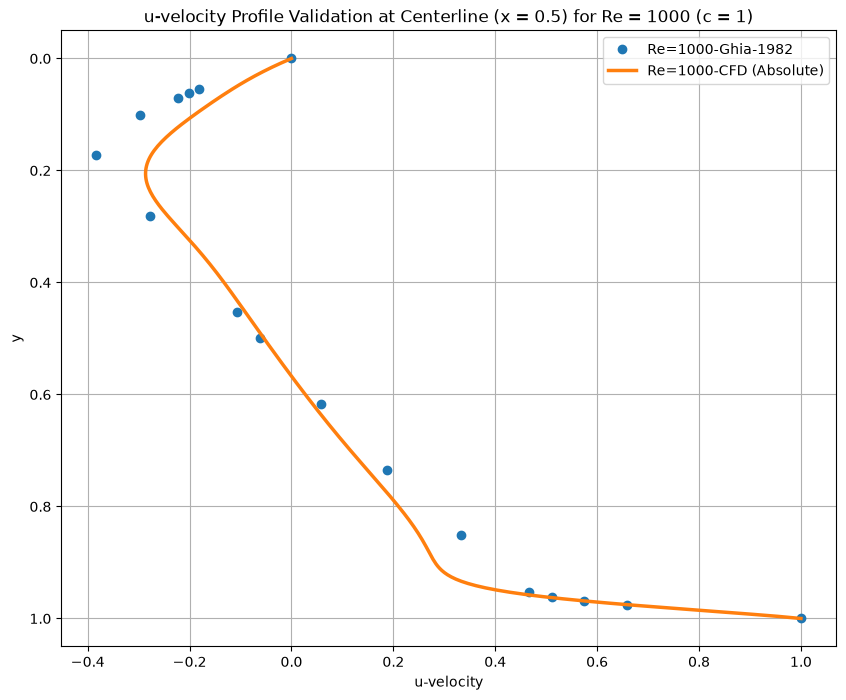

In [21]:
# validation plot for absolute u variation in y at x = 0.5 (at Re = 1000, v = 0.001)

plt.figure(figsize=(10, 8))

ghia_absolute_u = df['Re=1000'].values

# plotting the Ghia's comparison dots for Re=1000
plt.plot(ghia_absolute_u, df.index.values, 'o', label=f'Re=1000-Ghia-1982')

# extracting vertical centerline slice
u_centerline = u[int(nx / 2), :]

# plotting the raw, absolute code results as a continuous comparison line
plt.plot(u_centerline, y, '-', label='Re=1000-CFD (Absolute)', linewidth=2.5) 

plt.xlabel('u-velocity')
plt.ylabel('y')
plt.title(f'u-velocity Profile Validation at Centerline (x = 0.5) for Re = 1000 (c = {c})')
plt.legend()
plt.gca().invert_yaxis()  # keeping inversion mapping intact
plt.grid(True)
plt.show()